# 🧴 Cosmetics Products Data Cleaning Project  
### Data Analyst / Business Analyst Portfolio Project

This notebook demonstrates an end-to-end cleaning workflow for a Cosmetics Products dataset.  
We will explore, clean, transform, and prepare the data for analysis or dashboard visualization.

---

## 🎯 Objectives
- Import raw dataset  
- Identify data quality issues  
- Clean missing, inconsistent, duplicate values  
- Standardize formats  
- Export the final cleaned dataset  

---

## 📂 Files
- `data/raw_data.csv` — unclean dataset  
- `data/clean_data.csv` — final cleaned dataset  


## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



### Load the Dataset

In [3]:
df = pd.read_csv(r"C:\Users\Mayuresh\OneDrive\Desktop\_Project_\_DataSet_\_Raw_Cosmetic_Dataset.csv")  
df.head()


,Customer_Id,Gender,Age,City,First_purchase_date,Last_purchase_date,Total_Orders,Preferred_Category,Discount_Used_PCT,Delivery_Days,Ratings
0,CUST1000,Male,34,Mumbai,07-07-2023,22-12-2024,5,Fragrance,0.17,3.0,4.0
1,CUST1001,Female,35,Chennai,26-02-2023,13-03-2024,3,Skincare,0.15,4.1,4.6
2,CUST1002,Male,50,Delhi,20-01-2023,28-03-2024,6,Skincare,0.52,4.2,3.7
3,CUST1003,Male,37,Pune,30-09-2023,06-01-2024,6,Haircare,0.22,5.0,2.8
4,CUST1004,Male,30,Delhi,29-04-2023,15-06-2024,8,Haircare,0.35,2.4,2.5


# Initial Data Inspection


### Shape of Dataset

In [12]:
df.shape


(1000, 11)

### Columns

In [13]:
df.columns


Index(['Customer_Id', 'Gender', 'Age', 'City', 'First_purchase_date',
       'Last_purchase_date', 'Total_Orders', 'Preferred_Category',
       'Discount_Used_PCT', 'Delivery_Days', 'Ratings'],
      dtype='object')

### Basic Overview

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_Id          1000 non-null   object 
 1   Gender               1000 non-null   object 
 2   Age                  1000 non-null   int64  
 3   City                 1000 non-null   object 
 4   First_purchase_date  1000 non-null   object 
 5   Last_purchase_date   1000 non-null   object 
 6   Total_Orders         1000 non-null   int64  
 7   Preferred_Category   1000 non-null   object 
 8   Discount_Used_PCT    1000 non-null   float64
 9   Delivery_Days        1000 non-null   float64
 10  Ratings              1000 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 86.1+ KB


### Convert Object Date Columns to Datetime Format

In [19]:
df['First_purchase_date'] = pd.to_datetime(df['First_purchase_date'], format="%d-%m-%Y", errors='coerce')

In [20]:
df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], format="%d-%m-%Y", errors='coerce')


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer_Id          1000 non-null   object        
 1   Gender               1000 non-null   object        
 2   Age                  1000 non-null   int64         
 3   City                 1000 non-null   object        
 4   First_purchase_date  1000 non-null   datetime64[ns]
 5   Last_purchase_date   1000 non-null   datetime64[ns]
 6   Total_Orders         1000 non-null   int64         
 7   Preferred_Category   1000 non-null   object        
 8   Discount_Used_PCT    1000 non-null   float64       
 9   Delivery_Days        1000 non-null   float64       
 10  Ratings              1000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(4)
memory usage: 86.1+ KB


### Preview Sample Rows

In [15]:
df.sample(5)


,Customer_Id,Gender,Age,City,First_purchase_date,Last_purchase_date,Total_Orders,Preferred_Category,Discount_Used_PCT,Delivery_Days,Ratings
790,CUST1790,Female,30,Delhi,01-05-2023,15-11-2024,1,Fragrance,0.24,2.2,4.5
446,CUST1446,Male,45,Delhi,15-02-2023,22-07-2024,6,Skincare,0.27,2.4,4.2
127,CUST1127,Male,36,Pune,06-08-2023,30-09-2024,8,Makeup,0.56,2.3,2.9
445,CUST1445,Male,43,Mumbai,07-05-2023,11-07-2024,1,Skincare,0.10,5.6,4.9
130,CUST1130,Female,35,Delhi,27-04-2023,03-08-2024,8,Makeup,0.67,4.2,2.9


## Handle Missing & Blank Values

### Replace blank strings with NaN

In [16]:
df.replace("", np.nan, inplace=True)


### Check Missing Values Again

In [17]:
df.isnull().sum()


Customer_Id            0
Gender                 0
Age                    0
City                   0
First_purchase_date    0
Last_purchase_date     0
Total_Orders           0
Preferred_Category     0
Discount_Used_PCT      0
Delivery_Days          0
Ratings                0
dtype: int64

### Convert Date Columns to datetime

In [18]:
df['First_purchase_date'] = pd.to_datetime(df['First_purchase_date'], errors='coerce')
df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], errors='coerce')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer_Id          1000 non-null   object        
 1   Gender               1000 non-null   object        
 2   Age                  1000 non-null   int64         
 3   City                 1000 non-null   object        
 4   First_purchase_date  414 non-null    datetime64[ns]
 5   Last_purchase_date   1000 non-null   datetime64[ns]
 6   Total_Orders         1000 non-null   int64         
 7   Preferred_Category   1000 non-null   object        
 8   Discount_Used_PCT    1000 non-null   float64       
 9   Delivery_Days        1000 non-null   float64       
 10  Ratings              1000 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(4)
memory usage: 86.1+ KB


C:\Users\Mayuresh\AppData\Local\Temp\ipykernel_428\1437785646.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Last_purchase_date'] = pd.to_datetime(df['Last_purchase_date'], errors='coerce')


## Detect Outliers
### Summary Statistics

In [19]:
df.describe()


,Age,First_purchase_date,Last_purchase_date,Total_Orders,Discount_Used_PCT,Delivery_Days,Ratings
count,1000.00000,414,1000,1000.000000,1000.000000,1000.00000,1000.000000
mean,38.52100,2023-06-20 16:45:13.043478528,2024-07-16 04:04:48.000000256,5.044000,0.347040,4.42680,3.702000
min,18.00000,2023-01-01 00:00:00,2024-01-02 00:00:00,1.000000,0.000000,2.00000,2.500000
25%,28.00000,2023-04-01 00:00:00,2024-04-30 00:00:00,3.000000,0.170000,3.20000,3.100000
50%,39.00000,2023-07-01 00:00:00,2024-07-24 12:00:00,5.000000,0.340000,4.40000,3.700000
75%,49.00000,2023-10-02 00:00:00,2024-10-08 00:00:00,7.000000,0.530000,5.60000,4.300000
max,59.00000,2023-12-10 00:00:00,2024-12-31 00:00:00,9.000000,0.700000,7.00000,5.000000
std,12.01757,NaN,NaN,2.518016,0.202821,1.42269,0.712027


### Boxplots for Numerical Columns (Optional)

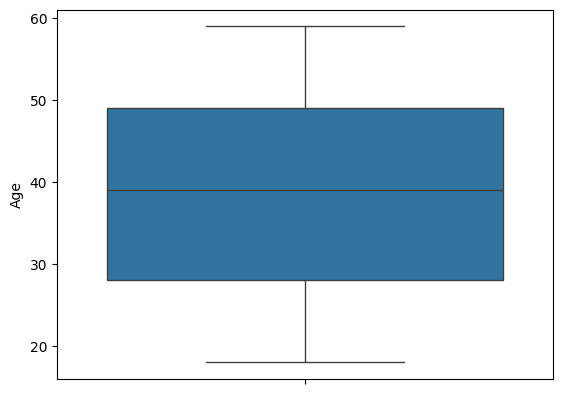

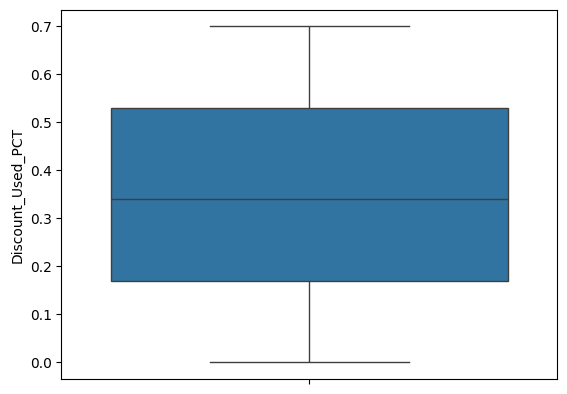

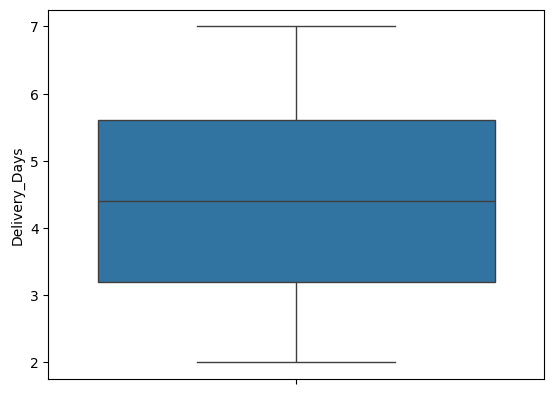

In [20]:
sns.boxplot(df['Age'])
plt.show()

sns.boxplot(df['Discount_Used_PCT'])
plt.show()

sns.boxplot(df['Delivery_Days'])
plt.show()


## Clean Text & Categorical Columns
### Strip spaces & standardize case

In [21]:
df['Gender'] = df['Gender'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()
df['Preferred_Category'] = df['Preferred_Category'].str.strip().str.title()


### Check categories

In [22]:
df['Gender'].value_counts()


Gender
Female    510
Male      490
Name: count, dtype: int64

In [23]:
df['Preferred_Category'].value_counts()


Preferred_Category
Makeup       270
Skincare     249
Haircare     246
Fragrance    235
Name: count, dtype: int64

## Remove Duplicates
### Check duplicates

In [24]:
df.duplicated().sum()


np.int64(0)

### Drop duplicates

In [25]:
df.drop_duplicates(inplace=True)


### Save Cleaned Dataset

In [6]:
df.to_csv(r"C:\Users\Mayuresh\OneDrive\Desktop\_Project_\_DataSet_\_Clean_Raw_DataSet_by_Jupyter.csv", index=False)
